## Task 2: Unsupervised Domain Adaptation — CS6304 PA1
```
MyDrive/atml_assignment1/
├── data/          ← PACS images
├── task1/         ← (existing)
├── Task 2/        ← code (upload once)
└── task2/         ← outputs (auto-created)
    ├── checkpoints/
    ├── results/
    └── splits/
```
> ⚠️ **GPU runtime required**

---
### Cell 0 — Mount Drive, paths, imports

In [13]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, shutil, json, random, warnings
import numpy as np
import torch
import torch.nn as nn
warnings.filterwarnings('ignore')

# ── Same root as Task 1 ───────────────────────────────────────────────────
DRIVE_ROOT      = '/content/drive/MyDrive/atml_assignment1'
DATA_DIR        = os.path.join(DRIVE_ROOT, 'data')
TASK2_CKPT_DIR  = os.path.join(DRIVE_ROOT, 'task2', 'checkpoints')
TASK2_OUT_DIR   = os.path.join(DRIVE_ROOT, 'task2', 'results')
TASK2_SPLIT_DIR = os.path.join(DRIVE_ROOT, 'task2', 'splits')
SPLITS_PATH     = os.path.join(TASK2_SPLIT_DIR, 'pacs_sketch_seed6304.json')

for d in [DATA_DIR, TASK2_CKPT_DIR, TASK2_OUT_DIR, TASK2_SPLIT_DIR]:
    os.makedirs(d, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

print(f'\nPaths:')
print(f'  DRIVE_ROOT : {DRIVE_ROOT}')
print(f'  DATA_DIR   : {DATA_DIR}')
print(f'  Checkpoints: {TASK2_CKPT_DIR}')
print(f'  Results    : {TASK2_OUT_DIR}')
print(f'  Splits     : {SPLITS_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device : cuda
GPU    : Tesla T4

Paths:
  DRIVE_ROOT : /content/drive/MyDrive/atml_assignment1
  DATA_DIR   : /content/drive/MyDrive/atml_assignment1/data
  Checkpoints: /content/drive/MyDrive/atml_assignment1/task2/checkpoints
  Results    : /content/drive/MyDrive/atml_assignment1/task2/results
  Splits     : /content/drive/MyDrive/atml_assignment1/task2/splits/pacs_sketch_seed6304.json


---
### Cell 1 — Copy code & add to path

In [14]:
CODE_ON_DRIVE = os.path.join(DRIVE_ROOT, 'Task 2')
CODE_LOCAL    = '/content/task2'

assert os.path.isdir(CODE_ON_DRIVE), (
    f'Code not found: {CODE_ON_DRIVE}\n'
    'Upload Task 2/ folder to MyDrive/atml_assignment1/ first.'
)

# Always fresh copy to pick up edits
if os.path.isdir(CODE_LOCAL):
    shutil.rmtree(CODE_LOCAL)
print('Copying code from Drive ...')
shutil.copytree(CODE_ON_DRIVE, CODE_LOCAL)

if CODE_LOCAL not in sys.path:
    sys.path.insert(0, CODE_LOCAL)

# Change working dir so configs/ can be found
os.chdir(CODE_LOCAL)

print(f'Working dir: {os.getcwd()}')
print(f'Contents   : {sorted(os.listdir(CODE_LOCAL))}')

Copying code from Drive ...
Working dir: /content/task2
Contents   : ['29100133_PA1_Task2_Launcher.ipynb', 'configs', 'evaluate_final.py', 'evaluation', 'methods', 'models', 'results', 'shared', 'train.py']


In [15]:
for pkg in ['models', 'methods', 'evaluation', 'shared']:
    init_path = f'/content/task2/{pkg}/__init__.py'
    if not os.path.exists(init_path):
        open(init_path, 'w').close()
        print(f'Created {init_path}')
    else:
        print(f'Already exists: {init_path}')

Already exists: /content/task2/models/__init__.py
Already exists: /content/task2/methods/__init__.py
Already exists: /content/task2/evaluation/__init__.py
Already exists: /content/task2/shared/__init__.py


---
### Cell 2 — Install dependencies

In [16]:
!pip install -q pyyaml scikit-learn
print('Done.')

Done.


---
### Cell 3 — Detect correct PACS folder
The Kaggle archive has `pacs_data/` (real images) and `dct2_images/` (DCT).  
This cell picks the right one.

In [23]:
PACS_DOMAINS = ['art_painting', 'cartoon', 'photo', 'sketch']

candidates = []
for root, dirs, _ in os.walk(DATA_DIR):
    if set(PACS_DOMAINS).issubset(set(dirs)):
        candidates.append(root)

if not candidates:
    print('❌ No PACS data found. Run the PACS Setup cell below first.')
else:
    for c in candidates:
        sample_dir = os.path.join(c, 'photo', 'dog')
        files = sorted(os.listdir(sample_dir))[:3] if os.path.isdir(sample_dir) else []
        tag = '✅ REAL' if 'dct' not in c.lower() else '❌ DCT'
        print(f'{tag}  {c}  →  {files}')

    real = [c for c in candidates if 'dct' not in c.lower()]
    DATA_DIR = real[0] if real else candidates[0]
    print(f'\n✅ DATA_DIR = {DATA_DIR}')

❌ DCT  /content/drive/MyDrive/atml_assignment1/data/dct2_images/dct2_images  →  ['dct_056_0001.jpg', 'dct_056_0002.jpg', 'dct_056_0003.jpg']
✅ REAL  /content/drive/MyDrive/atml_assignment1/data/pacs_data/pacs_data  →  ['056_0001.jpg', '056_0002.jpg', '056_0003.jpg']

✅ DATA_DIR = /content/drive/MyDrive/atml_assignment1/data/pacs_data/pacs_data


---
### Cell 4 — Import Task 2 modules & create run helper
**This runs training directly in the notebook process** (like Task 1) — no subprocess.

In [17]:
from types import SimpleNamespace
from train import train
from evaluate_final import run_evaluation

def run_train(method, study=None, lambda_mmd=None, grl_max_alpha=None):
    """Call train() directly in this process — saves go straight to Drive."""
    args = SimpleNamespace(
        method        = method,
        data_root     = DATA_DIR,
        checkpoints_dir = TASK2_CKPT_DIR,
        results_dir   = TASK2_OUT_DIR,
        splits_path   = SPLITS_PATH,
        study         = study,
        lambda_mmd    = lambda_mmd,
        grl_max_alpha = grl_max_alpha,
    )
    train(args)
    # Verify checkpoint saved
    from train import checkpoint_name
    study_kw = {}
    if lambda_mmd is not None: study_kw['lambda_mmd'] = lambda_mmd
    if grl_max_alpha is not None: study_kw['grl_max_alpha'] = grl_max_alpha
    name = checkpoint_name(method, study, **study_kw)
    ckpt = os.path.join(TASK2_CKPT_DIR, f'{name}_best.pth')
    if os.path.isfile(ckpt):
        sz = os.path.getsize(ckpt) / 1048576
        print(f'\n✅ Checkpoint verified: {ckpt} ({sz:.1f} MB)')
    else:
        print(f'\n❌ Checkpoint NOT found at {ckpt}')

def run_eval():
    """Call run_evaluation() directly in this process."""
    args = SimpleNamespace(
        data_root     = DATA_DIR,
        checkpoints_dir = TASK2_CKPT_DIR,
        results_dir   = TASK2_OUT_DIR,
        splits_path   = SPLITS_PATH,
    )
    run_evaluation(args)
    eval_json = os.path.join(TASK2_OUT_DIR, 'final_evaluation.json')
    if os.path.isfile(eval_json):
        print(f'\n✅ Results saved: {eval_json}')
    else:
        print(f'\n❌ Results NOT found at {eval_json}')

print('run_train() and run_eval() ready.')

run_train() and run_eval() ready.


---
### 📦 PACS Setup — only needed ONCE (skip if already extracted)

In [22]:
import zipfile
data_base = '/content/drive/MyDrive/atml_assignment1/data'
zip_path = os.path.join(data_base, 'PACS.zip')

if not os.path.isfile(zip_path):
    print(f'No PACS.zip at {zip_path} — maybe already extracted?')
    # Quick check
    if candidates:
        print(f'PACS data found at: {DATA_DIR}')
    else:
        print('Upload PACS.zip to atml_assignment1/data/ on Drive first.')
else:
    size_mb = os.path.getsize(zip_path) // 1_048_576
    print(f'Found PACS.zip ({size_mb} MB) — extracting ...')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(data_base)
    os.remove(zip_path)
    print('✅ Done. Re-run Cell 3 above to detect the correct folder.')

Found PACS.zip (525 MB) — extracting ...
✅ Done. Re-run Cell 3 above to detect the correct folder.


In [24]:
import os

# ── All checkpoints to delete ─────────────────────────────────────────────────
to_delete = [
    # Main comparison checkpoints
    os.path.join(TASK2_CKPT_DIR, 'source_only_best.pth'),
    os.path.join(TASK2_CKPT_DIR, 'dan_best.pth'),
    os.path.join(TASK2_CKPT_DIR, 'dann_best.pth'),
    os.path.join(TASK2_CKPT_DIR, 'cdan_best.pth'),
]

# Add any controlled study checkpoints found in the directory
study_files = [
    os.path.join(TASK2_CKPT_DIR, f)
    for f in os.listdir(TASK2_CKPT_DIR)
    if 'lambda_mmd' in f or 'grl_alpha' in f
]
to_delete.extend(study_files)

# ── Delete ────────────────────────────────────────────────────────────────────
for path in to_delete:
    if os.path.isfile(path):
        os.remove(path)
        print(f'Deleted : {path}')
    else:
        print(f'Not found (already clean): {path}')

# ── Verify ────────────────────────────────────────────────────────────────────
print('\nRemaining checkpoints:')
remaining = os.listdir(TASK2_CKPT_DIR)
if remaining:
    for f in sorted(remaining):
        sz = os.path.getsize(os.path.join(TASK2_CKPT_DIR, f)) / 1048576
        print(f'  {sz:6.1f} MB  {f}')
else:
    print('  (empty — clean slate, ready to retrain)')

Not found (already clean): /content/drive/MyDrive/atml_assignment1/task2/checkpoints/source_only_best.pth
Not found (already clean): /content/drive/MyDrive/atml_assignment1/task2/checkpoints/dan_best.pth
Not found (already clean): /content/drive/MyDrive/atml_assignment1/task2/checkpoints/dann_best.pth
Not found (already clean): /content/drive/MyDrive/atml_assignment1/task2/checkpoints/cdan_best.pth

Remaining checkpoints:
  (empty — clean slate, ready to retrain)


---
### Step 1 — Source-Only ERM
Checkpoint → `task2/checkpoints/source_only_best.pth` (also Task 3 baseline)

In [25]:
run_train('source_only')

[train] Method: source_only  |  Device: cuda
[train] Run name: source_only
[pacs] Dataset found at /content/drive/MyDrive/atml_assignment1/data/pacs_data/pacs_data
[protocol] Creating stratified 80/20 splits (seed 6304)…
  [photo] total=1670  train=1336  val=334
  [art_painting] total=2048  train=1638  val=410
  [cartoon] total=2344  train=1875  val=469
[protocol] Splits saved → /content/drive/MyDrive/atml_assignment1/task2/splits/pacs_sketch_seed6304.json
[train] Steps/epoch: 167  |  Total steps: 5010
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 112MB/s] 


[train] No checkpoint found — starting from scratch.
Epoch [  1/30]  cls_loss=0.6515  total_loss=0.6515  | mean_src_F1=0.8848  ← best
  [ckpt] Saved → /content/drive/MyDrive/atml_assignment1/task2/checkpoints/source_only_best.pth  (42.7 MB)
Epoch [  2/30]  cls_loss=0.3094  total_loss=0.3094  | mean_src_F1=0.9115  ← best
  [ckpt] Saved → /content/drive/MyDrive/atml_assignment1/task2/checkpoints/source_only_best.pth  (42.7 MB)
Epoch [  3/30]  cls_loss=0.2314  total_loss=0.2314  | mean_src_F1=0.9133  ← best
  [ckpt] Saved → /content/drive/MyDrive/atml_assignment1/task2/checkpoints/source_only_best.pth  (42.7 MB)
Epoch [  4/30]  cls_loss=0.2111  total_loss=0.2111  | mean_src_F1=0.8756
Epoch [  5/30]  cls_loss=0.1720  total_loss=0.1720  | mean_src_F1=0.9041
Epoch [  6/30]  cls_loss=0.1221  total_loss=0.1221  | mean_src_F1=0.9250  ← best
  [ckpt] Saved → /content/drive/MyDrive/atml_assignment1/task2/checkpoints/source_only_best.pth  (42.7 MB)
Epoch [  7/30]  cls_loss=0.1246  total_loss=0.124

---
### Step 2 — DAN

In [26]:
run_train('dan')

[train] Method: dan  |  Device: cuda
[train] Run name: dan
[pacs] Dataset found at /content/drive/MyDrive/atml_assignment1/data/pacs_data/pacs_data
[protocol] Loading splits from /content/drive/MyDrive/atml_assignment1/task2/splits/pacs_sketch_seed6304.json
[train] Steps/epoch: 167  |  Total steps: 5010
[train] No checkpoint found — starting from scratch.
Epoch [  1/30]  cls_loss=0.6697  mmd_loss=0.2455  total_loss=0.9152  | mean_src_F1=0.8925  ← best
  [ckpt] Saved → /content/drive/MyDrive/atml_assignment1/task2/checkpoints/dan_best.pth  (42.7 MB)
Epoch [  2/30]  cls_loss=0.3071  mmd_loss=0.1992  total_loss=0.5063  | mean_src_F1=0.8974  ← best
  [ckpt] Saved → /content/drive/MyDrive/atml_assignment1/task2/checkpoints/dan_best.pth  (42.7 MB)
Epoch [  3/30]  cls_loss=0.2153  mmd_loss=0.1881  total_loss=0.4033  | mean_src_F1=0.8735
Epoch [  4/30]  cls_loss=0.1823  mmd_loss=0.1888  total_loss=0.3710  | mean_src_F1=0.8498
Epoch [  5/30]  cls_loss=0.1758  mmd_loss=0.1832  total_loss=0.3590 

---
### Step 3 — DANN

In [27]:
run_train('dann')

[train] Method: dann  |  Device: cuda
[train] Run name: dann
[pacs] Dataset found at /content/drive/MyDrive/atml_assignment1/data/pacs_data/pacs_data
[protocol] Loading splits from /content/drive/MyDrive/atml_assignment1/task2/splits/pacs_sketch_seed6304.json
[train] Steps/epoch: 167  |  Total steps: 5010
[train] No checkpoint found — starting from scratch.
Epoch [  1/30]  cls_loss=0.5783  domain_loss=0.6198  total_loss=1.1981  | mean_src_F1=0.8914  ← best
  [ckpt] Saved → /content/drive/MyDrive/atml_assignment1/task2/checkpoints/dann_best.pth  (43.2 MB)
Epoch [  2/30]  cls_loss=0.3066  domain_loss=0.7810  total_loss=1.0876  | mean_src_F1=0.9148  ← best
  [ckpt] Saved → /content/drive/MyDrive/atml_assignment1/task2/checkpoints/dann_best.pth  (43.2 MB)
Epoch [  3/30]  cls_loss=0.2327  domain_loss=0.7167  total_loss=0.9494  | mean_src_F1=0.8787
Epoch [  4/30]  cls_loss=0.1937  domain_loss=0.7146  total_loss=0.9083  | mean_src_F1=0.9143
Epoch [  5/30]  cls_loss=0.1457  domain_loss=0.7183 

---
### Step 4 — CDAN

In [28]:
run_train('cdan')

[train] Method: cdan  |  Device: cuda
[train] Run name: cdan
[pacs] Dataset found at /content/drive/MyDrive/atml_assignment1/data/pacs_data/pacs_data
[protocol] Loading splits from /content/drive/MyDrive/atml_assignment1/task2/splits/pacs_sketch_seed6304.json
[train] Steps/epoch: 167  |  Total steps: 5010
[train] No checkpoint found — starting from scratch.
Epoch [  1/30]  cls_loss=0.6354  domain_loss=0.6047  total_loss=1.2401  | mean_src_F1=0.9017  ← best
  [ckpt] Saved → /content/drive/MyDrive/atml_assignment1/task2/checkpoints/cdan_best.pth  (46.2 MB)
Epoch [  2/30]  cls_loss=0.3134  domain_loss=0.6807  total_loss=0.9941  | mean_src_F1=0.8446
Epoch [  3/30]  cls_loss=0.2368  domain_loss=0.7506  total_loss=0.9874  | mean_src_F1=0.8619
Epoch [  4/30]  cls_loss=0.2119  domain_loss=0.7548  total_loss=0.9667  | mean_src_F1=0.8965
Epoch [  5/30]  cls_loss=0.1553  domain_loss=0.7066  total_loss=0.8619  | mean_src_F1=0.8874
Epoch [  6/30]  cls_loss=0.2014  domain_loss=0.7440  total_loss=0.9

---
### Step 5 — Final Evaluation
> ⚠️ Sketch labels used here for the FIRST time.

In [29]:
run_eval()

[eval] Device: cuda
[pacs] Dataset found at /content/drive/MyDrive/atml_assignment1/data/pacs_data/pacs_data
[protocol] Loading splits from /content/drive/MyDrive/atml_assignment1/task2/splits/pacs_sketch_seed6304.json

  Evaluating: Source-only
  [source_only] loaded from epoch 9  (src val F1=0.9325)

  Source-val results:
    photo               acc=0.9641  F1=0.9588
    art_painting        acc=0.8902  F1=0.8852
    cartoon             acc=0.9467  F1=0.9536
    Mean                acc=0.9337  F1=0.9325

  Target (Sketch):   acc=0.6024  F1=0.6350
  Domain separability: 0.9959  (0.50 = chance)

  Per-class target accuracy:

Class          Accuracy
------------------------
  dog            0.3601
  elephant       0.9514
  giraffe        0.4754
  guitar         0.7385
  horse          0.4534
  house          0.9500
  person         0.8250

  Evaluating: DAN
  [dan] loaded from epoch 11  (src val F1=0.9239)

  Source-val results:
    photo               acc=0.9581  F1=0.9513
    art_paint

---
### Step 6 — Controlled Study (DAN: vary λ_MMD)

In [30]:
for lmmd in [0.1, 1.0, 10.0]:
    print(f'\n{"#"*60}')
    print(f'#  DAN  lambda_mmd = {lmmd}')
    print(f'{"#"*60}')
    run_train('dan', study='lambda_mmd', lambda_mmd=lmmd)


############################################################
#  DAN  lambda_mmd = 0.1
############################################################
[train] Method: dan  |  Device: cuda
[train] Run name: dan_lambda_mmd0.1
[pacs] Dataset found at /content/drive/MyDrive/atml_assignment1/data/pacs_data/pacs_data
[protocol] Loading splits from /content/drive/MyDrive/atml_assignment1/task2/splits/pacs_sketch_seed6304.json
[train] Steps/epoch: 167  |  Total steps: 5010
[train] No checkpoint found — starting from scratch.
Epoch [  1/30]  cls_loss=0.6442  mmd_loss=0.3822  total_loss=0.6825  | mean_src_F1=0.8745  ← best
  [ckpt] Saved → /content/drive/MyDrive/atml_assignment1/task2/checkpoints/dan_lambda_mmd0.1_best.pth  (42.7 MB)
Epoch [  2/30]  cls_loss=0.3026  mmd_loss=0.2580  total_loss=0.3284  | mean_src_F1=0.9276  ← best
  [ckpt] Saved → /content/drive/MyDrive/atml_assignment1/task2/checkpoints/dan_lambda_mmd0.1_best.pth  (42.7 MB)
Epoch [  3/30]  cls_loss=0.2135  mmd_loss=0.2383  total_lo

---
### Verify all saved files

In [31]:
print('=== Checkpoints ===')
for f in sorted(os.listdir(TASK2_CKPT_DIR)):
    sz = os.path.getsize(os.path.join(TASK2_CKPT_DIR, f)) / 1048576
    print(f'  {sz:6.1f} MB  {f}')

print('\n=== Results ===')
for f in sorted(os.listdir(TASK2_OUT_DIR)):
    sz = os.path.getsize(os.path.join(TASK2_OUT_DIR, f)) / 1048576
    print(f'  {sz:6.1f} MB  {f}')

print('\n=== Splits ===')
for f in sorted(os.listdir(TASK2_SPLIT_DIR)):
    sz = os.path.getsize(os.path.join(TASK2_SPLIT_DIR, f)) / 1048576
    print(f'  {sz:6.1f} MB  {f}')

=== Checkpoints ===
    46.2 MB  cdan_best.pth
    42.7 MB  dan_best.pth
    42.7 MB  dan_lambda_mmd0.1_best.pth
    42.7 MB  dan_lambda_mmd1.0_best.pth
    42.7 MB  dan_lambda_mmd10.0_best.pth
    43.2 MB  dann_best.pth
    42.7 MB  source_only_best.pth

=== Results ===
     0.0 MB  cdan_curves.json
     0.1 MB  cdan_curves.png
     0.0 MB  cdan_source_val.json
     0.0 MB  controlled_study_target.json
     0.0 MB  dan_curves.json
     0.1 MB  dan_curves.png
     0.0 MB  dan_lambda_mmd0.1_curves.json
     0.1 MB  dan_lambda_mmd0.1_curves.png
     0.0 MB  dan_lambda_mmd0.1_source_val.json
     0.0 MB  dan_lambda_mmd1.0_curves.json
     0.1 MB  dan_lambda_mmd1.0_curves.png
     0.0 MB  dan_lambda_mmd1.0_source_val.json
     0.0 MB  dan_lambda_mmd10.0_curves.json
     0.1 MB  dan_lambda_mmd10.0_curves.png
     0.0 MB  dan_lambda_mmd10.0_source_val.json
     0.0 MB  dan_source_val.json
     0.0 MB  dann_curves.json
     0.1 MB  dann_curves.png
     0.0 MB  dann_source_val.json
     0.0 MB

---
### Display results inline

FINAL COMPARISON TABLE
Method            Photo   ArtPnt  Cartoon   MeanF1   TgtAcc    TgtF1    Delta   DomSep
------------------------------------------------------------------------------------------
Source-only      0.9641   0.8902   0.9467   0.9325   0.6024   0.6350  +0.0000   0.9959
DAN              0.9581   0.8902   0.9211   0.9239   0.6142   0.5836  +0.0117   0.8846
DANN             0.9551   0.9146   0.9318   0.9321   0.2655   0.1617  -0.3370   0.9986
CDAN             0.9491   0.8780   0.8827   0.9017   0.5475   0.5327  -0.0550   0.9945

── target_accuracy_comparison.png ──


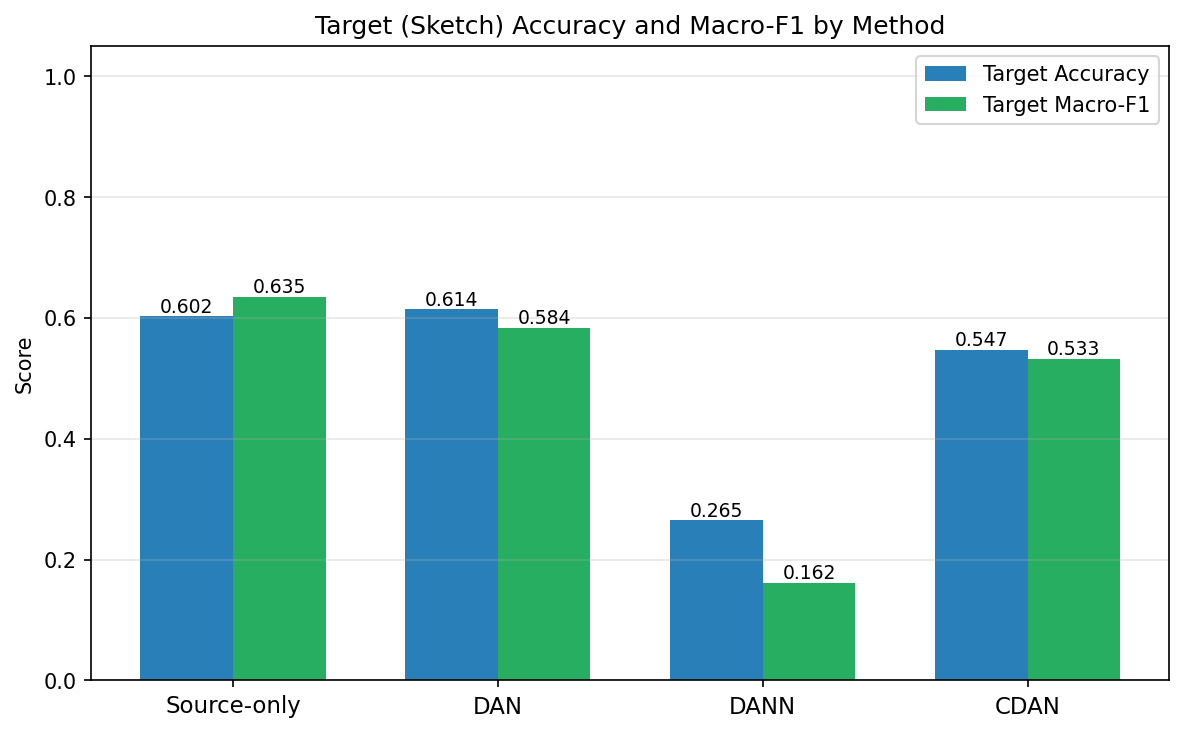


── domain_separability_vs_target.png ──


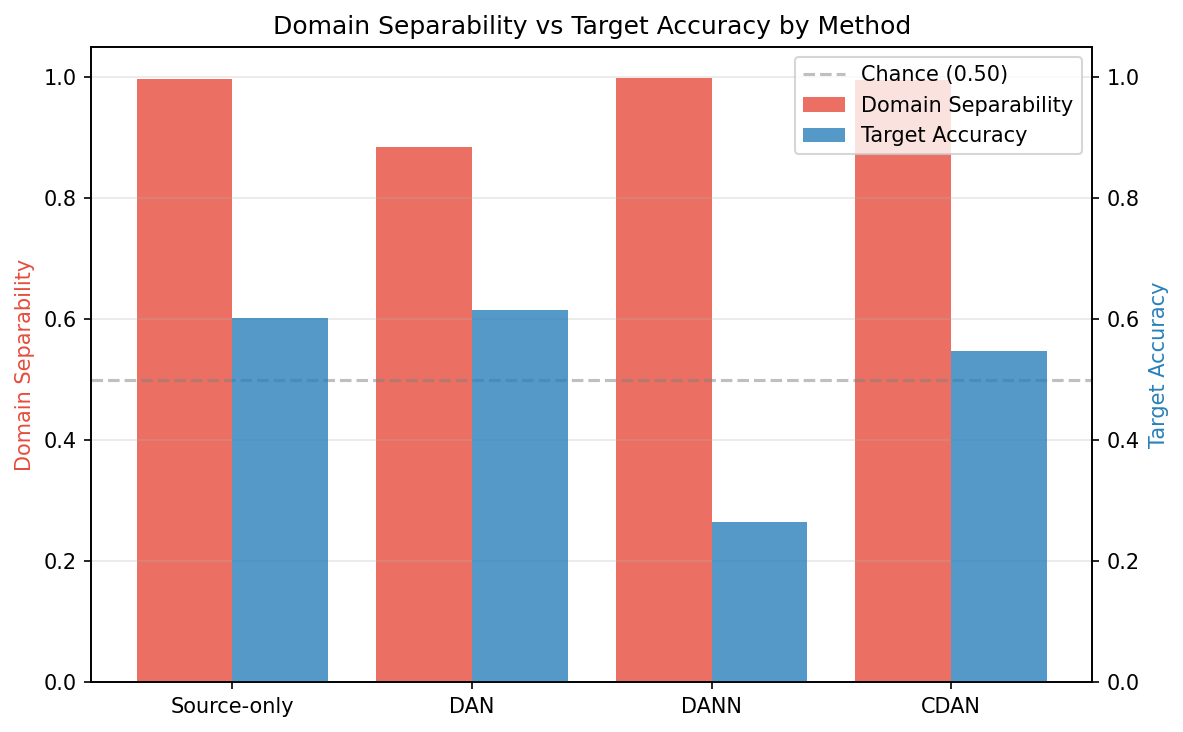


── per_class_deltas.png ──


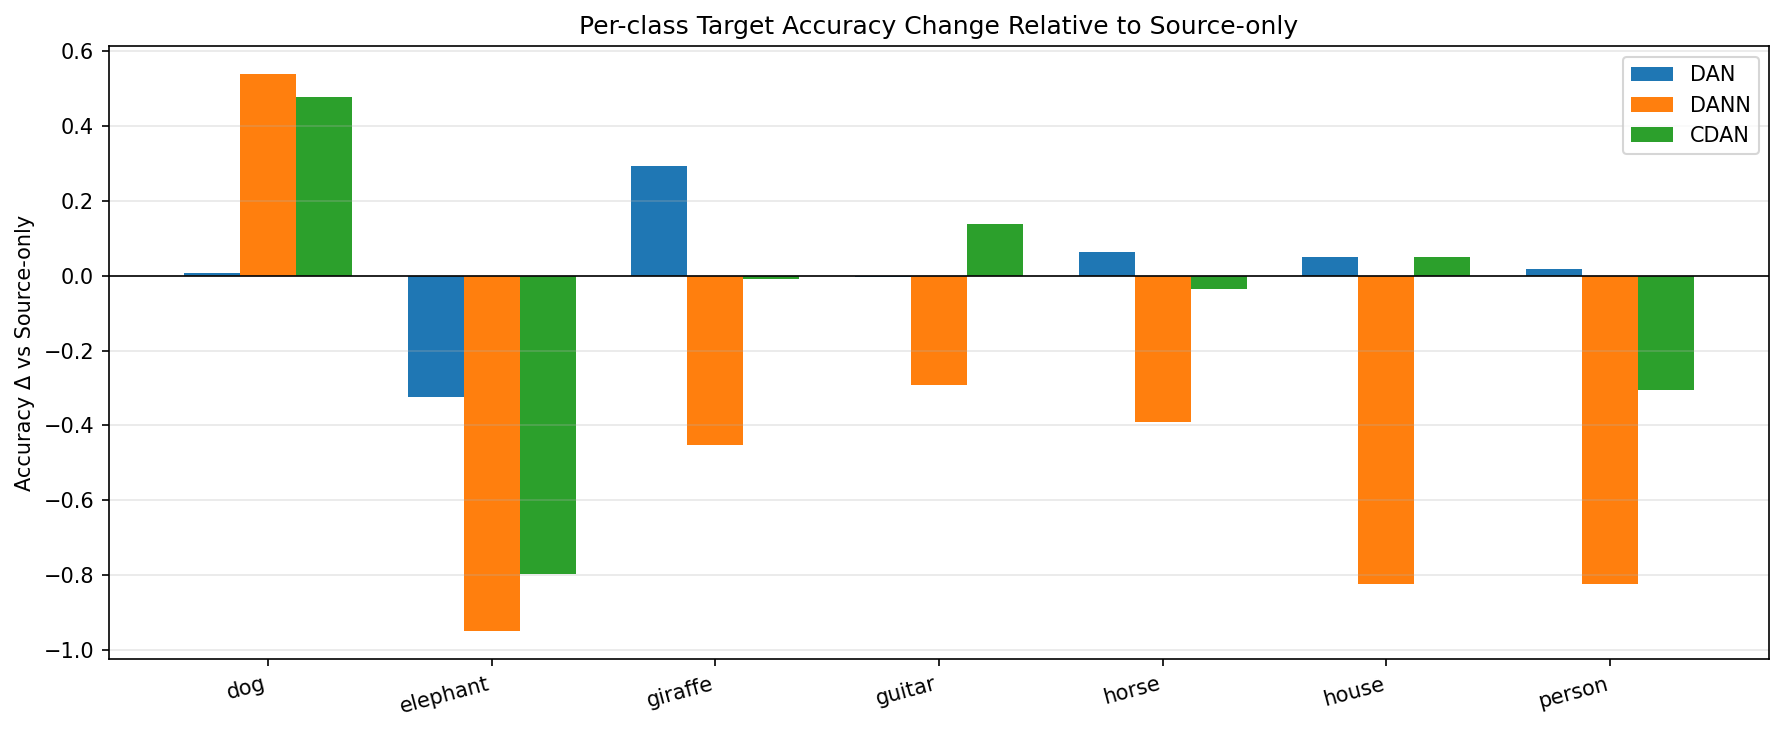


── source_only curves ──


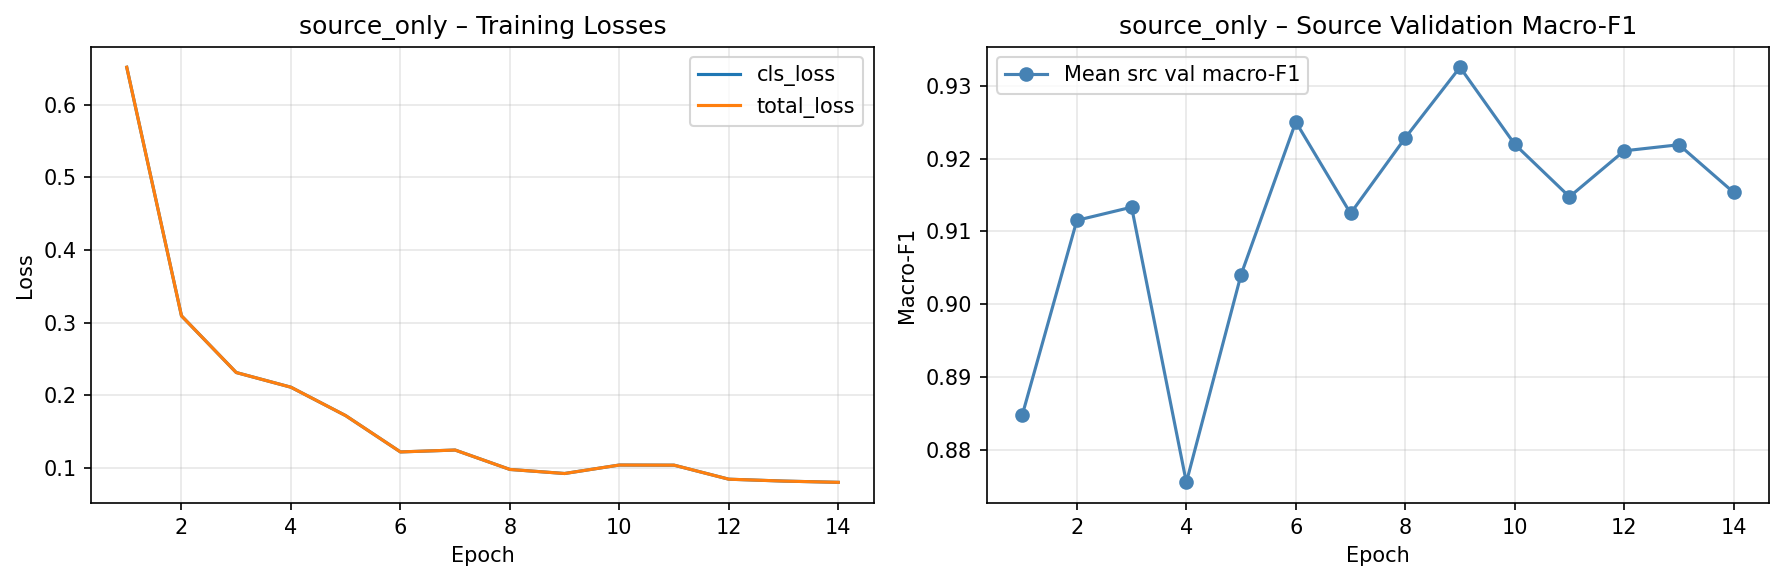


── dan curves ──


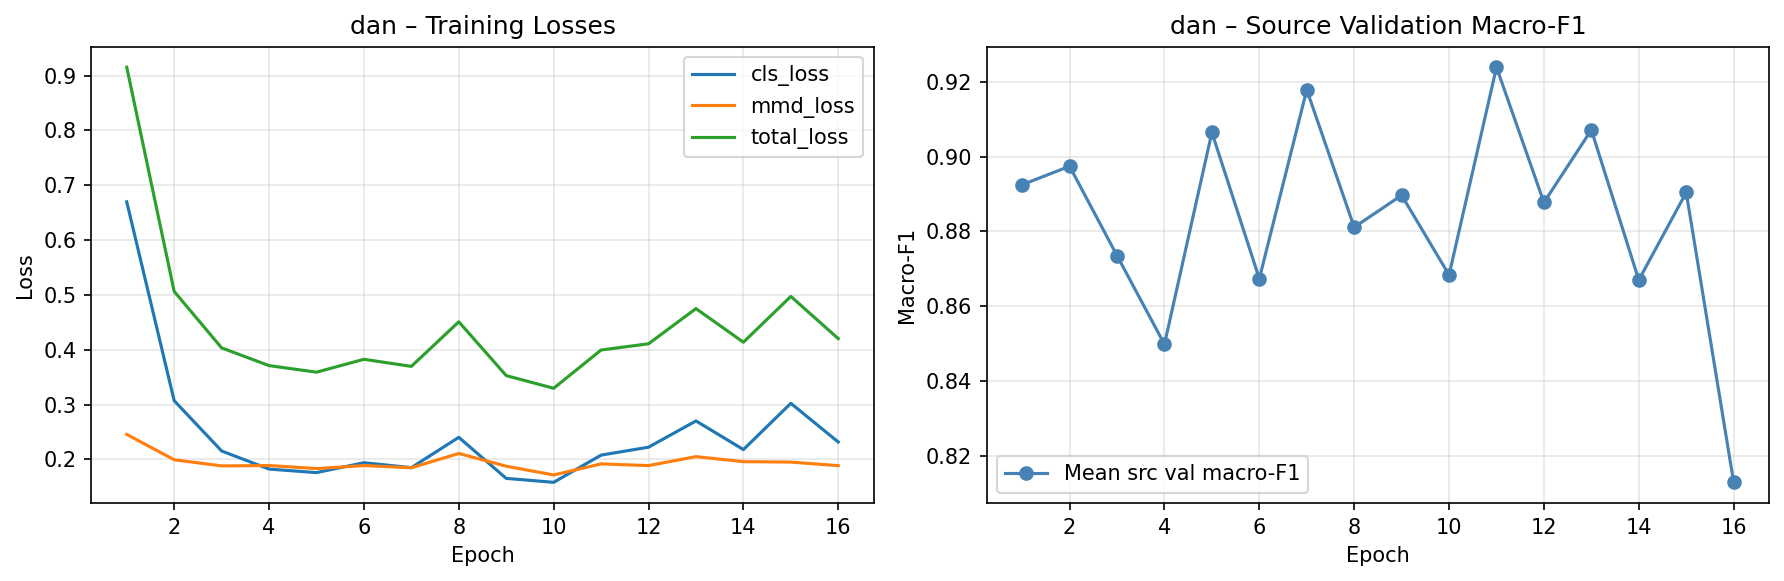


── dann curves ──


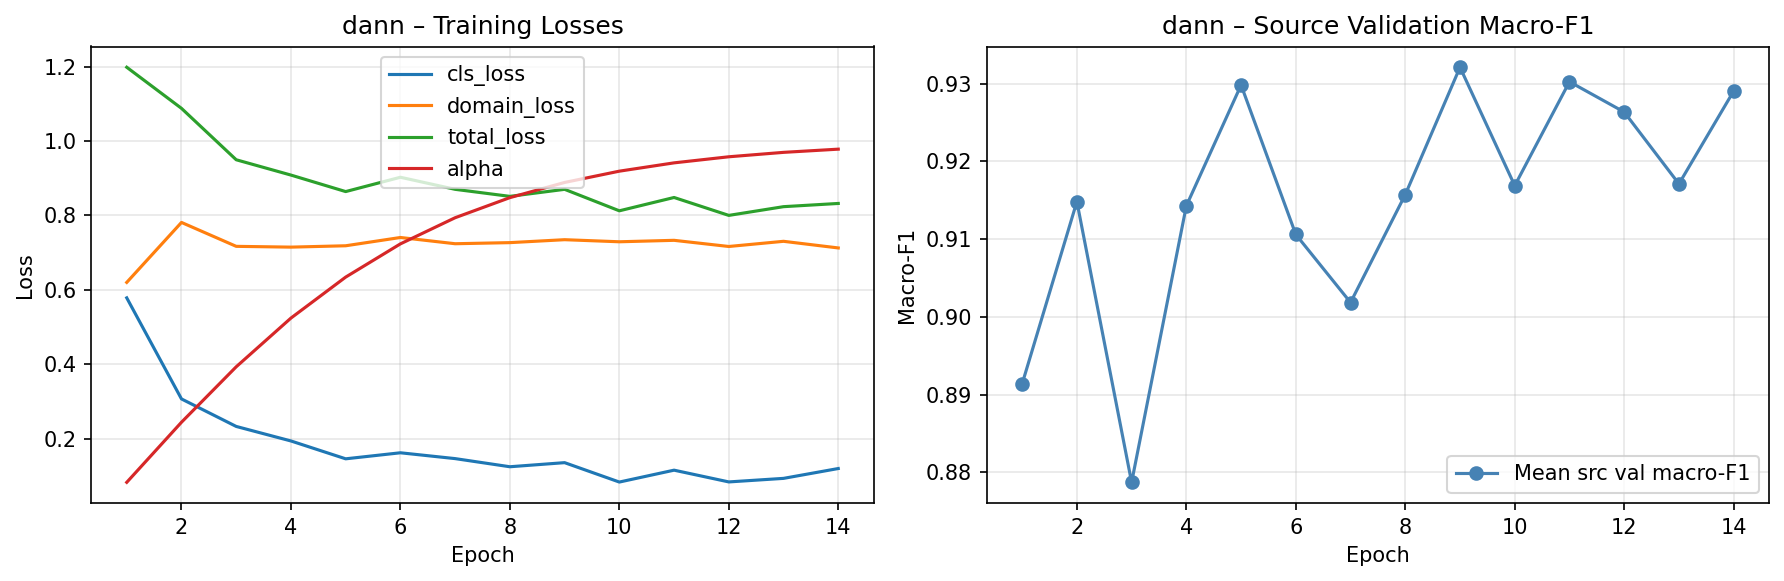


── cdan curves ──


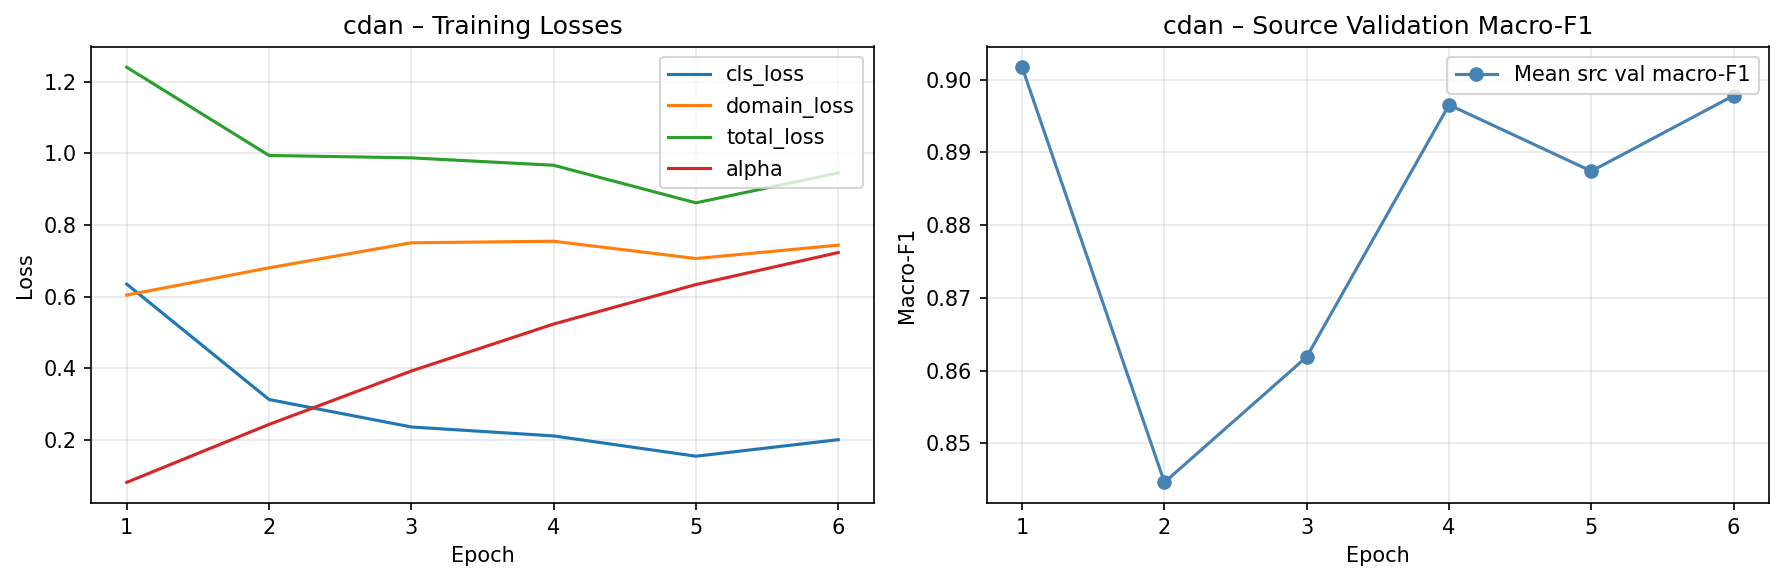

In [32]:
from IPython.display import Image, display

eval_path = os.path.join(TASK2_OUT_DIR, 'final_evaluation.json')
if os.path.isfile(eval_path):
    with open(eval_path) as f:
        results = json.load(f)
    labels = {'source_only':'Source-only','dan':'DAN','dann':'DANN','cdan':'CDAN'}
    print('=' * 90)
    print('FINAL COMPARISON TABLE')
    print('=' * 90)
    print(f'{"Method":<14} {"Photo":>8} {"ArtPnt":>8} {"Cartoon":>8} {"MeanF1":>8} {"TgtAcc":>8} {"TgtF1":>8} {"Delta":>8} {"DomSep":>8}')
    print('-' * 90)
    for method, label in labels.items():
        if method not in results: continue
        sv=results[method]['source_val']; tgt=results[method]['target']; dom=results[method]['domain_separability']
        print(f'{label:<14} {sv.get("photo",{}).get("accuracy",0):>8.4f} {sv.get("art_painting",{}).get("accuracy",0):>8.4f}'
              f' {sv.get("cartoon",{}).get("accuracy",0):>8.4f} {sv.get("mean",{}).get("macro_f1",0):>8.4f}'
              f' {tgt.get("accuracy",0):>8.4f} {tgt.get("macro_f1",0):>8.4f}'
              f' {tgt.get("delta_vs_source_only",0):>+8.4f} {dom.get("domain_separability",0):>8.4f}')
    print('=' * 90)
else:
    print('Run Step 5 first.')

for name in ['target_accuracy_comparison.png','domain_separability_vs_target.png',
             'per_class_deltas.png','controlled_study_dan_lambda.png']:
    p = os.path.join(TASK2_OUT_DIR, name)
    if os.path.isfile(p):
        print(f'\n── {name} ──')
        display(Image(p))

for m in ['source_only','dan','dann','cdan']:
    p = os.path.join(TASK2_OUT_DIR, f'{m}_curves.png')
    if os.path.isfile(p):
        print(f'\n── {m} curves ──')
        display(Image(p))